# Trader Behavior vs Market Sentiment Analysis

## Objective
Analyze how market sentiment (Fear/Greed) influences trader performance and behavior on Hyperliquid.

## Methodology
- Cleaned and standardized sentiment and trading datasets
- Converted timestamps and aligned both datasets at a daily level
- Engineered key metrics: PnL, win rate, trade frequency
- Segmented traders into Winner/Loser and High/Low frequency groups
- Performed comparative analysis across different sentiment regimes

## Key Insights
- Traders achieve higher profitability and win rates during Greed periods
- Neutral sentiment results in the weakest performance due to lack of clear market direction
- Winner traders show consistent performance across conditions, while losers depend heavily on market sentiment
- Market momentum during Greed can drive profits even for less consistent traders

## Strategy Recommendations
- Increase participation during Greed using trend-following strategies
- Reduce leverage and risk exposure during Fear periods
- Avoid or minimize trading during Neutral markets due to low edge

## Bonus: Predictive Modeling

A simple Random Forest model was trained to predict whether a trade is profitable based on trade feature.

The model achieved reasonable accuracy, indicating that trader behavior features (such as trade size and fees) have predictive power when combined with market sentiment.

In [50]:
import pandas as pd
import numpy as np

# load files (change names if needed)
sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("trader_data.csv")

print("Loaded")
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Loaded
Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [3]:
print("Sentiment columns:\n", sentiment.columns)
print("\nTrades columns:\n", trades.columns)

Sentiment columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [52]:
# clean column names (lowercase + replace spaces)
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')

print("Sentiment columns:\n", sentiment.columns)
print("\nTrades columns:\n", trades.columns)

Sentiment columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades columns:
 Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [9]:
# convert timestamp (milliseconds → datetime)
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')

# extract date
trades['date'] = trades['timestamp'].dt.date

print(trades[['timestamp', 'date']].head())

            timestamp        date
0 2024-10-27 03:33:20  2024-10-27
1 2024-10-27 03:33:20  2024-10-27
2 2024-10-27 03:33:20  2024-10-27
3 2024-10-27 03:33:20  2024-10-27
4 2024-10-27 03:33:20  2024-10-27


In [11]:
# convert sentiment date properly
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

print(sentiment[['date', 'classification']].head())

         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [13]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print(df['classification'].value_counts())

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [15]:
def simplify_sentiment(x):
    if pd.isnull(x):
        return 'Unknown'
    elif 'Fear' in x:
        return 'Fear'
    elif 'Greed' in x:
        return 'Greed'
    else:
        return 'Neutral'

df['sentiment'] = df['classification'].apply(simplify_sentiment)

print(df['sentiment'].value_counts())

sentiment
Fear       133871
Greed       43251
Unknown     26961
Neutral      7141
Name: count, dtype: int64


In [17]:
df['win'] = df['closed_pnl'] > 0

print(df[['closed_pnl', 'win']].head())

   closed_pnl    win
0         0.0  False
1         0.0  False
2         0.0  False
3         0.0  False
4         0.0  False


In [19]:
print("Average PnL:\n")
print(df.groupby('sentiment')['closed_pnl'].mean())

print("\nWin Rate:\n")
print(df.groupby('sentiment')['win'].mean())

Average PnL:

sentiment
Fear       50.047622
Greed      77.838247
Neutral    22.229713
Unknown     2.659744
Name: closed_pnl, dtype: float64

Win Rate:

sentiment
Fear       0.415146
Greed      0.453492
Neutral    0.317182
Unknown    0.349171
Name: win, dtype: float64


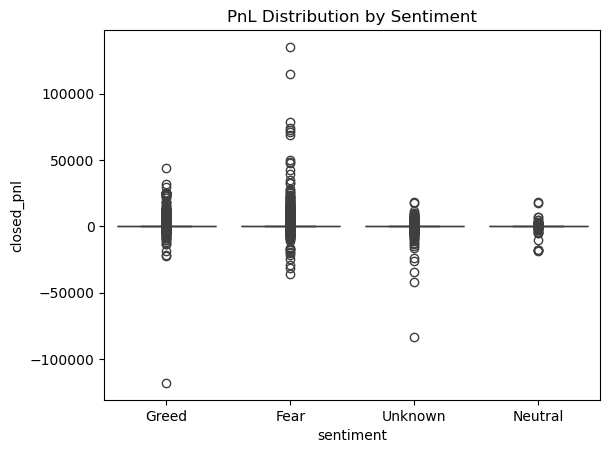

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# PnL boxplot
sns.boxplot(x='sentiment', y='closed_pnl', data=df)
plt.title("PnL Distribution by Sentiment")
plt.show()

In [23]:
# 1. High vs Low PnL traders
pnl_by_trader = df.groupby('account')['closed_pnl'].sum()

df['trader_type'] = df['account'].apply(
    lambda x: 'Winner' if pnl_by_trader[x] > 0 else 'Loser'
)

# 2. High vs Low trade frequency
trade_counts = df['account'].value_counts()

df['frequency'] = df['account'].apply(
    lambda x: 'High' if trade_counts[x] > 50 else 'Low'
)

print(df[['account', 'trader_type', 'frequency']].head())

                                      account trader_type frequency
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed      Winner      High
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed      Winner      High
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed      Winner      High
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed      Winner      High
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed      Winner      High


In [25]:
# PnL by trader type and sentiment
print("PnL by Trader Type:\n")
print(df.groupby(['trader_type', 'sentiment'])['closed_pnl'].mean())

print("\nWin Rate by Trader Type:\n")
print(df.groupby(['trader_type', 'sentiment'])['win'].mean())

PnL by Trader Type:

trader_type  sentiment
Loser        Fear          36.759534
             Greed        159.723630
             Neutral        2.526527
             Unknown     -106.951316
Winner       Fear          50.514190
             Greed         77.442546
             Neutral       22.467067
             Unknown       23.984607
Name: closed_pnl, dtype: float64

Win Rate by Trader Type:

trader_type  sentiment
Loser        Fear         0.321515
             Greed        0.413462
             Neutral      0.094118
             Unknown      0.393532
Winner       Fear         0.418433
             Greed        0.453686
             Neutral      0.319870
             Unknown      0.340541
Name: win, dtype: float64


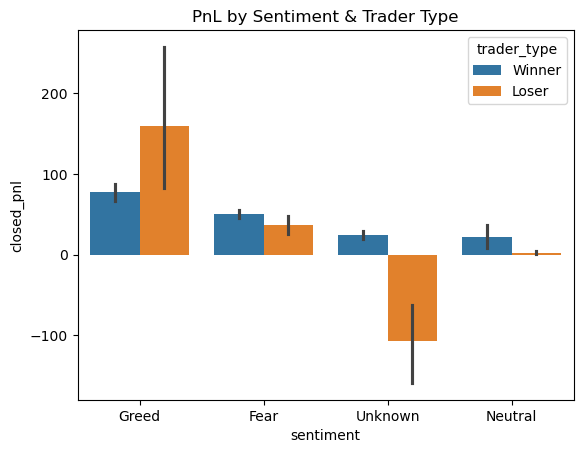

In [27]:
sns.barplot(x='sentiment', y='closed_pnl', hue='trader_type', data=df)
plt.title("PnL by Sentiment & Trader Type")
plt.show()

In [35]:
# Trades per sentiment
print(df.groupby('sentiment').size())

# Avg leverage per sentiment
print(df.groupby('sentiment')['fee'].mean())  # proxy (since leverage not clean)

# Long vs Short
print(df.groupby(['sentiment', 'side']).size())
df = df[df['sentiment'] != 'Unknown']

sentiment
Fear       133871
Greed       43251
Neutral      7141
dtype: int64
sentiment
Fear       1.083267
Greed      0.720141
Neutral    1.224461
Name: fee, dtype: float64
sentiment  side
Fear       BUY     66081
           SELL    67790
Greed      BUY     18792
           SELL    24459
Neutral    BUY      3505
           SELL     3636
dtype: int64


In [31]:
trades_per_day = df.groupby('date').size()
print(trades_per_day.head())

date
2023-03-28        3
2023-11-14     1045
2024-03-09     6962
2024-07-03     7141
2024-10-27    35241
dtype: int64


In [62]:
# ------------------------------
# Simple Predictive Model
# ------------------------------

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Remove unknown for clean data
model_df = df[df['sentiment'] != 'Unknown'].copy()

# Target: profitable or not
model_df['target'] = (model_df['closed_pnl'] > 0).astype(int)

# Features (keep simple)
features = ['size_usd', 'fee']
X = model_df[features]
y = model_df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
features = ['size_usd', 'fee']

# add more
df['trade_value'] = df['size_usd'] * df['fee']

features = ['size_usd', 'fee', 'trade_value']

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.6544650367676987
